In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
xlk = yf.download("XLK", start="1999-12-03", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [3]:
xlk.head()

Price,Close,High,Low,Open,Volume
Ticker,XLK,XLK,XLK,XLK,XLK
Date,,,,,
1999-12-03,18.486349,18.672610,18.381578,18.486349,1246200
1999-12-06,18.614403,18.754098,18.369936,18.428142,694800
1999-12-07,18.660961,18.742450,18.451418,18.742450,409000
1999-12-08,18.463076,18.672619,18.439793,18.463076,815800
1999-12-09,18.416498,18.719171,18.102184,18.649324,2375000


In [4]:
xlk["Return"] = np.log(xlk["Close"] / xlk["Close"].shift(1))
xlk["DollarVolume"] = xlk["Close"] * xlk["Volume"]
xlk["ILLIQ"] = np.abs(xlk["Return"]) / xlk["DollarVolume"]

In [5]:
xlk["Volatility"] = xlk["Return"].rolling(20).std()

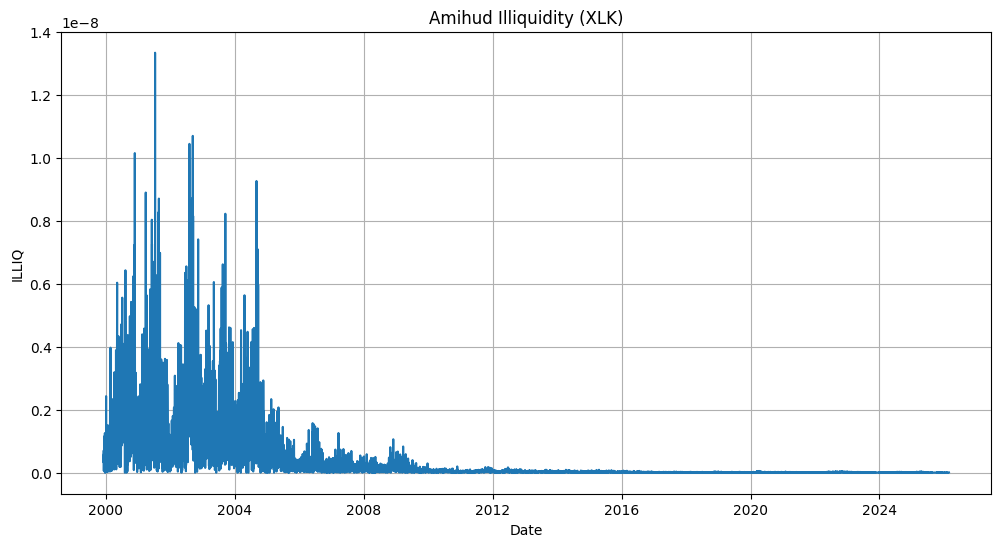

In [6]:
plt.figure(figsize=(12,6))
plt.plot(xlk.index, xlk["ILLIQ"])
plt.title("Amihud Illiquidity (XLK)")
plt.xlabel("Date")
plt.ylabel("ILLIQ")
plt.grid(True)
plt.show()

In [7]:
#Since the Amihud illiquidity series is highly skewed with occasional extreme spikes, 
# we apply a logarithmic transformation to reduce skewness and stabilize variance before modeling.
xlk = xlk[xlk["ILLIQ"] > 0].copy()
xlk["Log_ILLIQ"] = np.log(xlk["ILLIQ"])

In [8]:
# ----------------------------
# Clean dataset for modeling
# ----------------------------

In [9]:
# Remove problematic values
xlk = xlk.replace([np.inf, -np.inf], np.nan)

In [10]:
# Target = next-day liquidity
xlk["Target"] = xlk["Log_ILLIQ"].shift(-1)

In [11]:
# Keep only rows where everything is defined
xlk = xlk.dropna()

In [12]:
xlk.head()

Price,Close,High,Low,Open,Volume,Return,DollarVolume,ILLIQ,Volatility,Log_ILLIQ,Target
Ticker,XLK,XLK,XLK,XLK,XLK,,,,,,
Date,,,,,,,,,,,
2000-01-03,20.652039,20.721888,19.930265,20.721888,1876200,0.028590,3.874735e+07,7.378538e-10,0.011666,-21.027275,-19.833614
2000-01-04,19.604300,20.395922,19.487884,20.116526,1091000,-0.052065,2.138829e+07,2.434282e-09,0.017364,-19.833614,-22.317029
2000-01-05,19.313259,19.767278,18.672976,19.278335,3812000,-0.014957,7.362214e+07,2.031596e-10,0.017802,-22.317029,-21.338385
2000-01-06,18.672976,19.406390,18.486711,19.092070,3340000,-0.033715,6.236774e+07,5.405766e-10,0.019326,-21.338385,-21.132869
2000-01-07,18.998941,18.998941,18.300451,18.486715,1372000,0.017306,2.606655e+07,6.639139e-10,0.019665,-21.132869,-20.799759


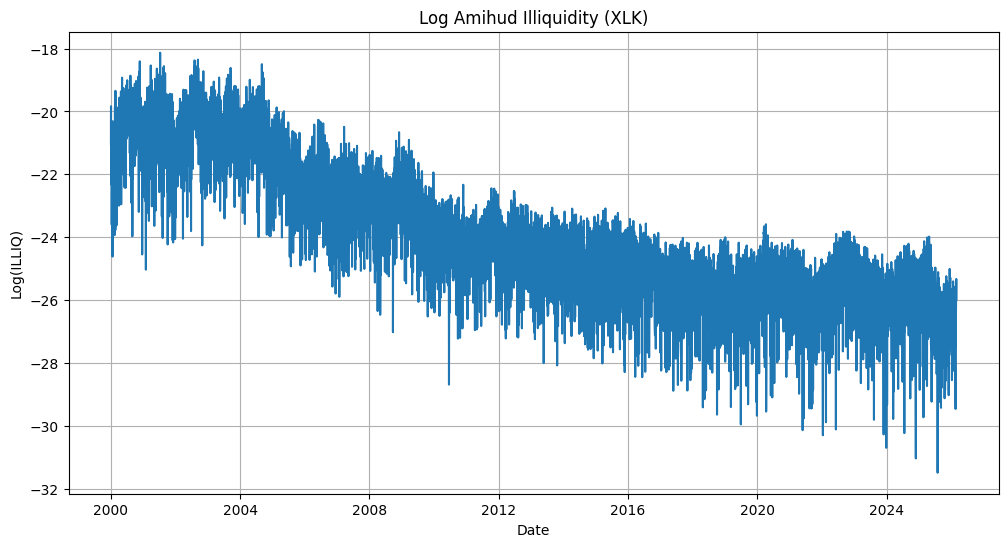

In [13]:
plt.figure(figsize=(12,6))
plt.plot(xlk.index, xlk["Log_ILLIQ"])
plt.title("Log Amihud Illiquidity (XLK)")
plt.xlabel("Date")
plt.ylabel("Log(ILLIQ)")
plt.grid(True)
plt.show()

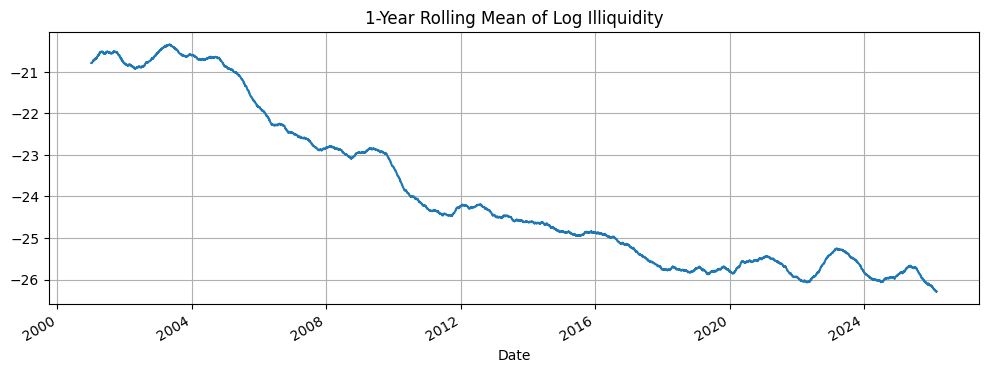

In [14]:
xlk["Log_ILLIQ"].rolling(252).mean().plot(figsize=(12,4))
plt.title("1-Year Rolling Mean of Log Illiquidity")
plt.grid(True)
plt.show()

## Naive Forecast

In [15]:
# ----------------------------
# Train/Test Split (Time Order!)
# ----------------------------

split_index = int(len(xlk) * 0.7)

train = xlk.iloc[:split_index]
test = xlk.iloc[split_index:]

In [16]:
# Naive predictions on test set

naive_pred = test["Log_ILLIQ"]
y_test = test["Target"]

In [17]:
mae_naive = mean_absolute_error(y_test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 1.1735779936848265
Naive RMSE: 1.5439831394417445


We use a persistence (naive) model as a baseline, assuming next-day liquidity equals today’s liquidity.

**Test performance:**

- MAE ≈ 1.17  
- RMSE ≈ 1.54  

On average, log liquidity changes by about 1.17 units per day in absolute value.

RMSE is noticeably larger than MAE (ratio ≈ 1.31), suggesting the presence of occasional large liquidity shocks. In a perfectly Gaussian setting this ratio would be closer to 1.25, so liquidity changes appear somewhat heavy-tailed.

## AR(p)

In [18]:
L = xlk["Log_ILLIQ"].dropna().copy()
# keep the date index for later
dates = L.index

In [19]:
# Build an integer-indexed version for statsmodels
L_int = pd.Series(L.to_numpy(), index=pd.RangeIndex(len(L)))

In [20]:
def walk_forward_ar_int(L_series_int, p=1, train_frac=0.7):
    n = len(L_series_int)
    split = int(n * train_frac)

    preds = np.empty(n - split)
    actual = L_series_int.iloc[split:].to_numpy()

    for i, t in enumerate(range(split, n)):
        train = L_series_int.iloc[:t]
        model = AutoReg(train, lags=p, old_names=False).fit()

        # Forecast next point (one-step ahead)
        preds[i] = model.forecast(steps=1).iloc[0]

    return actual, preds, split

In [21]:
# ---- AR(1) ----
actual_ar1, pred_ar1, split = walk_forward_ar_int(L_int, p=1, train_frac=0.7)

rmse_ar1 = np.sqrt(mean_squared_error(actual_ar1, pred_ar1))
mae_ar1 = mean_absolute_error(actual_ar1, pred_ar1)

print("AR(1) RMSE:", rmse_ar1)
print("AR(1) MAE:", mae_ar1)

AR(1) RMSE: 1.4741717870696611
AR(1) MAE: 1.1067506676925438


In [22]:
# ---- Naive on same test window: predict L_t = L_{t-1} ----

print("Naive (aligned) RMSE:", rmse_naive)
print("Naive (aligned) MAE:", mae_naive)

print("RMSE improvement vs naive:", (rmse_naive - rmse_ar1) / rmse_naive)
print("MAE improvement vs naive:", (mae_naive - mae_ar1) / mae_naive)

Naive (aligned) RMSE: 1.5439831394417445
Naive (aligned) MAE: 1.1735779936848265
RMSE improvement vs naive: 0.045215100209789166
MAE improvement vs naive: 0.05694323372787245


In [23]:
results = []
pred_store = {}  # store preds for later plotting

for p in [1, 2, 5, 10, 20, 30, 40]:
    actual, preds, _ = walk_forward_ar_int(L_int, p=p, train_frac=0.7)

    # # sanity check (optional)
    # assert split_check == split, "Split mismatch—check train_frac / split definition"

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    rmse_impr = (rmse_naive - rmse) / rmse_naive
    mae_impr  = (mae_naive  - mae)  / mae_naive

    results.append((p, rmse, mae, rmse_impr, mae_impr))
    pred_store[p] = (actual, preds)
    print(
        f"AR({p})  RMSE={rmse:.4f}  MAE={mae:.4f}  "
        f"RMSE_impr={rmse_impr}  "
        f"MAE_impr={mae_impr}"
    )

AR(1)  RMSE=1.4742  MAE=1.1068  RMSE_impr=0.045215100209789166  MAE_impr=0.05694323372787245
AR(2)  RMSE=1.2980  MAE=0.9704  RMSE_impr=0.1593249615509638  MAE_impr=0.17311442217616982
AR(5)  RMSE=1.1754  MAE=0.8841  RMSE_impr=0.23870890302111689  MAE_impr=0.24669562067497047
AR(10)  RMSE=1.1207  MAE=0.8495  RMSE_impr=0.27415046532123455  MAE_impr=0.2761767860897228
AR(20)  RMSE=1.1049  MAE=0.8412  RMSE_impr=0.28438118207453217  MAE_impr=0.28321990155221405
AR(30)  RMSE=1.1006  MAE=0.8402  RMSE_impr=0.28719883355767983  MAE_impr=0.2840411862247304
AR(40)  RMSE=1.0991  MAE=0.8400  RMSE_impr=0.2881610125054976  MAE_impr=0.28422610502441387


In [24]:
# --- Improvement vs lag p ---
p_vals = [r[0] for r in results]
rmse_imprs = [r[3] * 100 for r in results]
mae_imprs  = [r[4] * 100 for r in results]

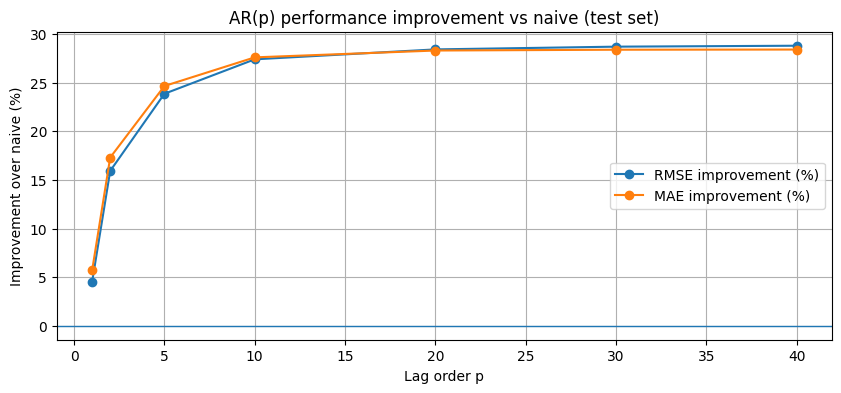

In [25]:
plt.figure(figsize=(10,4))
plt.plot(p_vals, rmse_imprs, marker="o", label="RMSE improvement (%)")
plt.plot(p_vals, mae_imprs, marker="o", label="MAE improvement (%)")
plt.axhline(0, linewidth=1)
plt.title("AR(p) performance improvement vs naive (test set)")
plt.xlabel("Lag order p")
plt.ylabel("Improvement over naive (%)")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# --- Actual vs Predicted for the AR(20) ---
test_dates = dates[split:]
actual_20, preds_20 = pred_store[20]

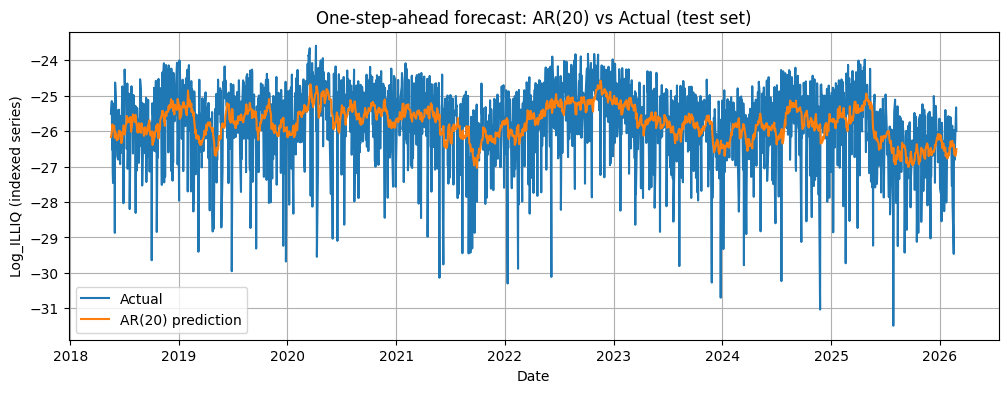

In [27]:
plt.figure(figsize=(12,4))
plt.plot(test_dates, actual_20, label="Actual")
plt.plot(test_dates, preds_20, label=f"AR({20}) prediction")
plt.title(f"One-step-ahead forecast: AR({20}) vs Actual (test set)")
plt.xlabel("Date")
plt.ylabel("Log_ILLIQ (indexed series)")
plt.grid(True)
plt.legend()
plt.show()

### AR Summary

As a first structured model beyond the naive persistence benchmark, we fit an **AR(p)** model and evaluate it using **walk-forward (expanding window) one-step-ahead forecasting** to respect time order and avoid look-ahead bias.

**Key result:** AR models substantially outperform the naive forecast on the test set, and the improvement increases with the lag order *p*.

- AR(1) already improves over naive (small but consistent gain).
- Performance improves steadily as more lags are added, with **strong gains up to ~20 lags**.
- After ~20 lags, improvements largely **saturate** (diminishing returns).

This pattern suggests that **liquidity is not a random walk**: it contains **multi-day memory**, meaning past liquidity levels help predict next-day liquidity. The concave improvement curve also indicates stable structure rather than “getting lucky” on a single lag choice.

For the remainder of the notebook, we use **AR(20)** as a simple, interpretable baseline model that captures most of the available autoregressive signal without adding unnecessary complexity.

## Regression With Volatility

In [28]:
# ----------------------------
# Build lagged design matrix
# ----------------------------

In [29]:
p = 20
xlk.replace([np.inf, -np.inf], np.nan)
# xlk = xlk.copy().replace([np.inf, -np.inf], np.nan)

Price,Close,High,Low,Open,Volume,Return,DollarVolume,ILLIQ,Volatility,Log_ILLIQ,Target
Ticker,XLK,XLK,XLK,XLK,XLK,,,,,,
Date,,,,,,,,,,,
2000-01-03,20.652039,20.721888,19.930265,20.721888,1876200,0.028590,3.874735e+07,7.378538e-10,0.011666,-21.027275,-19.833614
2000-01-04,19.604300,20.395922,19.487884,20.116526,1091000,-0.052065,2.138829e+07,2.434282e-09,0.017364,-19.833614,-22.317029
2000-01-05,19.313259,19.767278,18.672976,19.278335,3812000,-0.014957,7.362214e+07,2.031596e-10,0.017802,-22.317029,-21.338385
2000-01-06,18.672976,19.406390,18.486711,19.092070,3340000,-0.033715,6.236774e+07,5.405766e-10,0.019326,-21.338385,-21.132869
2000-01-07,18.998941,18.998941,18.300451,18.486715,1372000,0.017306,2.606655e+07,6.639139e-10,0.019665,-21.132869,-20.799759
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20,140.880005,141.750000,138.970001,139.199997,14942400,0.004767,2.105085e+09,2.264589e-12,0.016815,-26.813628,-25.919374
2026-02-23,138.520004,140.649994,137.889999,140.179993,22021900,-0.016894,3.050474e+09,5.538074e-12,0.017148,-25.919374,-25.676425


In [30]:
df = pd.DataFrame(index=xlk.index)
df["L"] = xlk["Log_ILLIQ"]
df["Vol_lag1"] = xlk["Volatility"].shift(1)

In [31]:
# Liquidity lags: L_{t-1} ... L_{t-20}
for i in range(1, p + 1):
    df[f"L_lag{i}"] = df["L"].shift(i)

In [32]:
# Keep rows where everything is defined
df = df.dropna(subset=["L", "Vol_lag1"] + [f"L_lag{i}" for i in range(1, p + 1)])
df.head()

,L,Vol_lag1,L_lag1,L_lag2,L_lag3,L_lag4,L_lag5,L_lag6,L_lag7,L_lag8,...,L_lag11,L_lag12,L_lag13,L_lag14,L_lag15,L_lag16,L_lag17,L_lag18,L_lag19,L_lag20
Date,,,,,,,,,,,,,,,,,,,,,
2000-02-01,-20.593572,0.026187,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,-24.618454,-22.734427,...,-21.598805,-22.341226,-23.600038,-21.355421,-20.799759,-21.132869,-21.338385,-22.317029,-19.833614,-21.027275
2000-02-02,-21.774866,0.025743,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,-24.618454,...,-22.137191,-21.598805,-22.341226,-23.600038,-21.355421,-20.799759,-21.132869,-21.338385,-22.317029,-19.833614
2000-02-03,-21.279749,0.023147,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,...,-23.602101,-22.137191,-21.598805,-22.341226,-23.600038,-21.355421,-20.799759,-21.132869,-21.338385,-22.317029
2000-02-04,-21.599391,0.023756,-21.279749,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,...,-22.734427,-23.602101,-22.137191,-21.598805,-22.341226,-23.600038,-21.355421,-20.799759,-21.132869,-21.338385
2000-02-07,-21.568353,0.022332,-21.599391,-21.279749,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,...,-24.618454,-22.734427,-23.602101,-22.137191,-21.598805,-22.341226,-23.600038,-21.355421,-20.799759,-21.132869


In [33]:
# Target and features
y = df["L"].to_numpy()
X_ar20 = df[[f"L_lag{i}" for i in range(1, p + 1)]].to_numpy()
X_ar20_vol = df[[f"L_lag{i}" for i in range(1, p + 1)] + ["Vol_lag1"]].to_numpy()

In [34]:
# ----------------------------
# Walk-forward evaluation setup
# ----------------------------
train_frac = 0.7
n = len(df)
split = int(n * train_frac)

def walk_forward_ridge(X, y, split, alpha=1e-6):
    # hard alignment checks (fail early with a clear message)
    if X.shape[0] != len(y):
        raise ValueError(f"X and y length mismatch: X has {X.shape[0]} rows, y has {len(y)}")
    if not (0 < split < len(y)):
        raise ValueError(f"Bad split={split} for len(y)={len(y)}")

    n = len(y)
    preds = np.empty(n - split)

    for j, t in enumerate(range(split, n)):
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(X[:t], y[:t])

        # X[t:t+1] is guaranteed non-empty now
        preds[j] = model.predict(X[t:t+1])[0]

    return preds

In [35]:
# Predictions
pred_ar20 = walk_forward_ridge(X_ar20, y, split)
pred_ar20_vol = walk_forward_ridge(X_ar20_vol, y, split)

y_test = y[split:]

In [36]:
rmse_ar20, mae_ar20 = np.sqrt(mean_squared_error(y_test, pred_ar20)), mean_absolute_error(y_test, pred_ar20)
rmse_ar20v, mae_ar20v = np.sqrt(mean_squared_error(y_test, pred_ar20_vol)), mean_absolute_error(y_test, pred_ar20_vol)

print(f"AR(20) only        RMSE={rmse_ar20:.4f}  MAE={mae_ar20:.4f}")
print(f"AR(20) + Vol_lag1  RMSE={rmse_ar20v:.4f}  MAE={mae_ar20v:.4f}")

print("\nImprovement of (AR20+Vol) vs (AR20):")
print("RMSE improvement:", (rmse_ar20 - rmse_ar20v) / rmse_ar20)
print("MAE improvement: ", (mae_ar20 - mae_ar20v) / mae_ar20)

AR(20) only        RMSE=1.1053  MAE=0.8412
AR(20) + Vol_lag1  RMSE=1.1054  MAE=0.8418

Improvement of (AR20+Vol) vs (AR20):
RMSE improvement: -9.336367942321297e-05
MAE improvement:  -0.0007895049488673611


In [37]:
gammas = []

for t in range(split, n):
    model = Ridge(alpha=1e-6, fit_intercept=True)
    model.fit(X_ar20_vol[:t], y[:t])
    # last coefficient corresponds to Vol_lag1
    gammas.append(model.coef_[-1])

gammas = np.array(gammas)

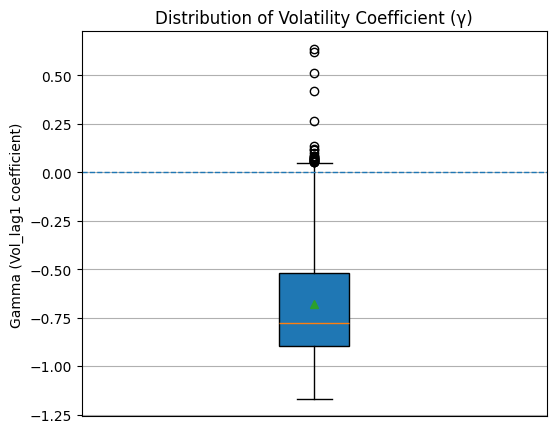

Mean gamma: -0.6798774006439052
Median gamma: -0.7789951691057709


In [38]:
plt.figure(figsize=(6,5))

plt.boxplot(
    gammas,
    vert=True,
    patch_artist=True,
    showmeans=True
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title("Distribution of Volatility Coefficient (γ)")
plt.ylabel("Gamma (Vol_lag1 coefficient)")
plt.xticks([])  # single distribution
plt.grid(True, axis="y")

plt.show()

print("Mean gamma:", gammas.mean())
print("Median gamma:", np.median(gammas))

The distribution of the volatility coefficient (γ) is predominantly negative, with:

- Mean γ ≈ −0.68  
- Median γ ≈ −0.78  

This indicates a stable negative relationship: higher volatility yesterday is associated with lower liquidity today, even after controlling for 20 liquidity lags. The sign aligns with financial intuition — liquidity tends to deteriorate during volatile periods.

However, adding lagged volatility does **not** meaningfully improve forecasting performance relative to AR(20). The predictive gains are effectively zero.

So far, this suggests that while volatility has a structurally consistent effect on liquidity, most of its predictive content may already be captured by liquidity’s own autoregressive structure.

To investigate this further, we next explore whether incorporating additional volatility lags changes the result.

In [39]:
# ---------------------------------------
# Add volatility lags to dataframe
# ---------------------------------------

max_vol_lag = 10

for j in range(1, max_vol_lag + 1):
    df[f"Vol_lag{j}"] = xlk["Volatility"].shift(j)

In [40]:
# Drop rows with new NaNs introduced by volatility lags
df_vol = df.dropna().copy()
df_vol.head()

,L,Vol_lag1,L_lag1,L_lag2,L_lag3,L_lag4,L_lag5,L_lag6,L_lag7,L_lag8,...,L_lag20,Vol_lag2,Vol_lag3,Vol_lag4,Vol_lag5,Vol_lag6,Vol_lag7,Vol_lag8,Vol_lag9,Vol_lag10
Date,,,,,,,,,,,,,,,,,,,,,
2000-02-01,-20.593572,0.026187,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,-24.618454,-22.734427,...,-21.027275,0.024793,0.023673,0.023996,0.022922,0.022436,0.021182,0.021182,0.021559,0.021644
2000-02-02,-21.774866,0.025743,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,-24.618454,...,-19.833614,0.026187,0.024793,0.023673,0.023996,0.022922,0.022436,0.021182,0.021182,0.021559
2000-02-03,-21.279749,0.023147,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,-20.311846,...,-22.317029,0.025743,0.026187,0.024793,0.023673,0.023996,0.022922,0.022436,0.021182,0.021182
2000-02-04,-21.599391,0.023756,-21.279749,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,-22.439562,...,-21.338385,0.023147,0.025743,0.026187,0.024793,0.023673,0.023996,0.022922,0.022436,0.021182
2000-02-07,-21.568353,0.022332,-21.599391,-21.279749,-21.774866,-20.593572,-21.137615,-21.624773,-22.286670,-20.685500,...,-21.132869,0.023756,0.023147,0.025743,0.026187,0.024793,0.023673,0.023996,0.022922,0.022436


In [41]:
# ---------------------------------------
# Loop over number of volatility lags
# ---------------------------------------

for k in [1, 2, 3, 5, 10]:
    
    vol_cols = [f"Vol_lag{j}" for j in range(1, k + 1)]
    X_aug = df_vol[[f"L_lag{i}" for i in range(1, 21)] + vol_cols].to_numpy()
    
    pred_aug = walk_forward_ridge(X_aug, y, split)
    
    rmse_aug = np.sqrt(mean_squared_error(y_test, pred_aug))
    
    improvement = (rmse_ar20 - rmse_aug) / rmse_ar20
    
    print(f"AR(20) + Vol(1..{k})  RMSE={rmse_aug:.6f}  "
          f"Incremental improvement={improvement:.4%}")

AR(20) + Vol(1..1)  RMSE=1.105414  Incremental improvement=-0.0093%
AR(20) + Vol(1..2)  RMSE=1.105583  Incremental improvement=-0.0247%
AR(20) + Vol(1..3)  RMSE=1.105626  Incremental improvement=-0.0285%
AR(20) + Vol(1..5)  RMSE=1.106014  Incremental improvement=-0.0636%
AR(20) + Vol(1..10)  RMSE=1.106920  Incremental improvement=-0.1456%


### Summary of Volatility-Augmented Findings

We extended the AR(20) model by incorporating lagged volatility to test whether volatility contains incremental predictive information for next-day liquidity.

The volatility coefficient (γ) is consistently negative (mean ≈ −0.68, median ≈ −0.78), indicating a stable structural relationship: higher volatility is associated with lower subsequent liquidity. This aligns with financial intuition, as liquidity tends to deteriorate during turbulent market conditions.

However, despite this economically meaningful relationship, adding volatility does **not** improve out-of-sample forecasting performance. The predictive gains are effectively zero, and including multiple volatility lags slightly worsens performance.

These results suggest that while volatility affects liquidity structurally, most of its predictive content is already embedded in liquidity’s own autoregressive dynamics. Increasing model complexity via additional volatility lags adds little forecasting value.

We therefore proceed with AR(20) as a parsimonious and empirically robust baseline.

## Gradient Boosting

In [42]:
xlk.head()

Price,Close,High,Low,Open,Volume,Return,DollarVolume,ILLIQ,Volatility,Log_ILLIQ,Target
Ticker,XLK,XLK,XLK,XLK,XLK,,,,,,
Date,,,,,,,,,,,
2000-01-03,20.652039,20.721888,19.930265,20.721888,1876200,0.028590,3.874735e+07,7.378538e-10,0.011666,-21.027275,-19.833614
2000-01-04,19.604300,20.395922,19.487884,20.116526,1091000,-0.052065,2.138829e+07,2.434282e-09,0.017364,-19.833614,-22.317029
2000-01-05,19.313259,19.767278,18.672976,19.278335,3812000,-0.014957,7.362214e+07,2.031596e-10,0.017802,-22.317029,-21.338385
2000-01-06,18.672976,19.406390,18.486711,19.092070,3340000,-0.033715,6.236774e+07,5.405766e-10,0.019326,-21.338385,-21.132869
2000-01-07,18.998941,18.998941,18.300451,18.486715,1372000,0.017306,2.606655e+07,6.639139e-10,0.019665,-21.132869,-20.799759


In [43]:
# FEATURE ENGINEERING

In [44]:
# --- Base frame ---
df = pd.DataFrame(index=xlk.index)
df["L"] = xlk["Log_ILLIQ"]
df["Vol"] = xlk["Volatility"]

In [45]:
df.head()

,L,Vol
Date,,
2000-01-03,-21.027275,0.011666
2000-01-04,-19.833614,0.017364
2000-01-05,-22.317029,0.017802
2000-01-06,-21.338385,0.019326
2000-01-07,-21.132869,0.019665


In [46]:
# --- Liquidity lags (core) ---
p = 20
for i in range(1, p + 1):
    df[f"L_lag{i}"] = df["L"].shift(i)

In [47]:
# --- Volatility lags + rolling vols (stress memory) ---
for j in [1, 2, 5, 10]:
    df[f"Vol_lag{j}"] = df["Vol"].shift(j)
# Earlier linear tests showed little incremental value,
# but nonlinear interactions may exist.

In [48]:
# Rolling vol features must be shifted by 1 to avoid using Vol_t when predicting L_t
for w in [5, 10, 20]:
    df[f"Vol_mean{w}"] = df["Vol"].rolling(w).mean().shift(1)
    df[f"Vol_std{w}"]  = df["Vol"].rolling(w).std().shift(1)
    
df.loc[:, df.columns.str.contains('Vol')].head()

,Vol,Vol_lag1,Vol_lag2,Vol_lag5,Vol_lag10,Vol_mean5,Vol_std5,Vol_mean10,Vol_std10,Vol_mean20,Vol_std20
Date,,,,,,,,,,,
2000-01-03,0.011666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,0.017364,0.011666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,0.017802,0.017364,0.011666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,0.019326,0.017802,0.017364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,0.019665,0.019326,0.017802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# --- Liquidity rolling features (state / momentum) ---
# Rolling liquidity features must be shifted by 1 to avoid using L_t when predicting L_t
for w in [5, 10, 20]:
    df[f"L_mean{w}"] = df["L"].rolling(w).mean().shift(1)
    df[f"L_std{w}"]  = df["L"].rolling(w).std().shift(1)

# Momentum features already use only past values (safe as written)
df["L_mom5"]  = df["L"].shift(1) - df["L"].shift(5)
df["L_mom20"] = df["L"].shift(1) - df["L"].shift(20)

In [50]:
# --- Seasonality features (calendar-known, no leakage) ---
idx = df.index
df["dow"] = idx.dayofweek
df["month"] = idx.month
df["is_month_end"] = idx.is_month_end.astype(int)
df["is_month_start"] = idx.is_month_start.astype(int)

df["day"] = idx.day
df["turn_of_month"] = ((df["day"] <= 3) | (df["day"] >= 28)).astype(int)

In [51]:
# --- Regime features (computed from PAST only to avoid leakage) ---
def expanding_quantile(s, q):
    # 252 is approximately 1 trading year
    return s.expanding(min_periods=252).quantile(q).shift(1)

In [52]:
# Rolling historical 90th and 99th percentile thresholds
df["Vol_q90"] = expanding_quantile(df["Vol"], 0.90)
df["Vol_q99"] = expanding_quantile(df["Vol"], 0.99)

In [53]:
# high_vol = 1 if yesterday’s volatility was unusually high.
df["high_vol"] = (df["Vol"].shift(1) > df["Vol_q90"]).astype(int)
# extreme_vol = 1 if yesterday’s volatility was in the historical top 1%.
df["extreme_vol"] = (df["Vol"].shift(1) > df["Vol_q99"]).astype(int)

In [54]:
# this says:
# Was yesterday’s liquidity in the worst 10% historically?
# Yes -> we are in an illiquid regime
df["L_q90"] = expanding_quantile(df["L"], 0.90)
df["illiquid_regime"] = (df["L"].shift(1) > df["L_q90"]).astype(int)

In [55]:
df = df.dropna()
df.head()

,L,Vol,L_lag1,L_lag2,L_lag3,L_lag4,L_lag5,L_lag6,L_lag7,L_lag8,...,is_month_end,is_month_start,day,turn_of_month,Vol_q90,Vol_q99,high_vol,extreme_vol,L_q90,illiquid_regime
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-04,-21.596035,0.050369,-19.902536,-20.370154,-21.614873,-22.728111,-21.900441,-21.192344,-20.425849,-24.548306,...,0,0,4,0,0.037490,0.041680,1,1,-19.531949,0
2001-01-05,-19.837115,0.051760,-21.596035,-19.902536,-20.370154,-21.614873,-22.728111,-21.900441,-21.192344,-20.425849,...,0,0,5,0,0.037596,0.041712,1,1,-19.532595,0
2001-01-08,-22.353801,0.051375,-19.837115,-21.596035,-19.902536,-20.370154,-21.614873,-22.728111,-21.900441,-21.192344,...,0,0,8,0,0.037679,0.045791,1,1,-19.533240,0
2001-01-09,-20.380157,0.050417,-22.353801,-19.837115,-21.596035,-19.902536,-20.370154,-21.614873,-22.728111,-21.900441,...,0,0,9,0,0.037798,0.050832,1,1,-19.533886,0
2001-01-10,-20.702121,0.050111,-20.380157,-22.353801,-19.837115,-21.596035,-19.902536,-20.370154,-21.614873,-22.728111,...,0,0,10,0,0.037927,0.050848,1,0,-19.534532,0


In [56]:
# ----------------------------
# Build X (features) and y (target)
# ----------------------------
features = [c for c in df.columns if c != "L"]
X = df[features].to_numpy()
y = df["L"].to_numpy()

train_frac = 0.7
split = int(len(y) * train_frac)
y_test = y[split:]

print("X shape:", X.shape, "y shape:", y.shape, "split index:", split)

X shape: (6252, 51) y shape: (6252,) split index: 4376


In [57]:
assert X.shape[0] == y.shape[0]
assert len(y_test) == (len(y) - split)

#### Little Feature Design Summary

We model next-day log illiquidity as a state variable that evolves gradually, occasionally shifts under stress, and may respond nonlinearly to market conditions.

**1. Autoregressive structure (core signal)**  
Liquidity is highly persistent. We therefore include up to 20 lags of log illiquidity, reflecting the multi-day memory identified in earlier linear tests.

**2. Volatility as a transmission channel**  
Volatility is introduced as a potential driver of liquidity deterioration. While linear models showed limited incremental forecasting power, nonlinear interactions may exist — for example, liquidity may respond differently once volatility crosses certain stress thresholds. Tree-based models are well suited to capture such effects.

**3. Rolling state variables (level & dispersion)**  
Rolling means and standard deviations of liquidity summarize recent regime state. Rather than forcing the model to infer regime shifts from raw lags alone, we explicitly provide smoothed indicators of liquidity level and instability.

**4. Momentum features**  
Liquidity momentum captures whether conditions are stabilizing or deteriorating over multiple horizons. These features help detect directional shifts that linear autoregressions may encode inefficiently.

**5. Calendar effects**  
Calendar variables (day-of-week, month-end indicators, turn-of-month) are included to account for institutional trading patterns and systematic rebalancing effects.

**6. Regime indicators (real-time, no leakage)**  
Extreme volatility and illiquidity regimes are defined using expanding quantiles rather than full-sample thresholds. This mimics real-time learning and avoids hindsight bias. All rolling and expanding features are shifted by one period to ensure strict out-of-sample validity.

Together, these features allow the gradient boosting model to capture persistence, nonlinear stress effects, regime shifts, and calendar structure within a fully time-consistent framework.

In [58]:
def walk_forward_hgb_refit(X, y, split, refit_every=5):
    """
    Predict y[t] using model trained on y[:t] and X[:t], refitting every 'refit_every' steps.
    This is walk-forward forecasting with periodic refits to control compute.
    """
    n = len(y)
    preds = np.empty(n - split)

    model = None
    last_fit_t = -10**9

    for j, t in enumerate(range(split, n)):
        if (t - last_fit_t) >= refit_every:
            model = HistGradientBoostingRegressor(
                max_depth=4,
                learning_rate=0.1,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=0
            )

            model.fit(X[:t], y[:t])
            last_fit_t = t

        preds[j] = model.predict(X[t:t+1])[0]

    return preds

In [59]:
pred_hgb = walk_forward_hgb_refit(X, y, split, refit_every=5)

In [60]:
y_test = y[split:]
rmse_hgb = np.sqrt(mean_squared_error(y_test, pred_hgb))
mae_hgb = mean_absolute_error(y_test, pred_hgb)

print(f"HGB (refit_every=5) RMSE={rmse_hgb:.4f}  MAE={mae_hgb:.4f}")

HGB (refit_every=5) RMSE=1.0611  MAE=0.7957


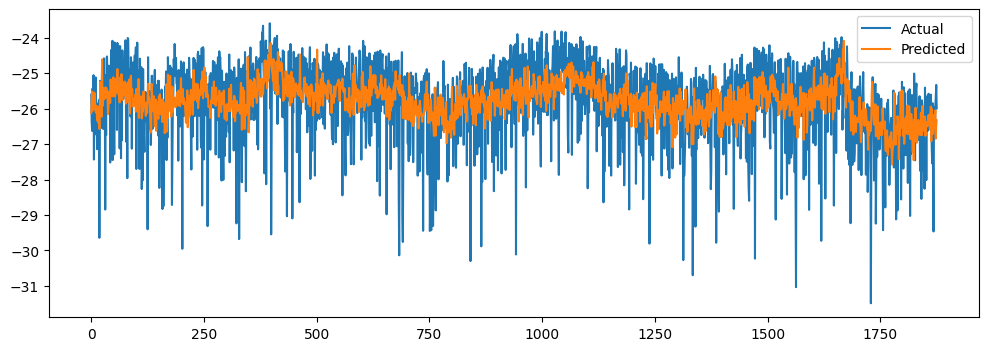

In [61]:
plt.figure(figsize=(12,4))
plt.plot(y_test, label="Actual")
plt.plot(pred_hgb, label="Predicted")
plt.legend()
plt.show()

### Leakage Tests

In [62]:
lag_cols = [f"L_lag{i}" for i in range(1, 21)]
X_ar20 = df[lag_cols].to_numpy()

pred_ar20_same = walk_forward_ridge(X_ar20, y, split, alpha=1e-6)

y_test = y[split:]
rmse_ar20_same = np.sqrt(mean_squared_error(y_test, pred_ar20_same))
mae_ar20_same  = mean_absolute_error(y_test, pred_ar20_same)

print(f"AR(20) on same df   RMSE={rmse_ar20_same:.4f}  MAE={mae_ar20_same:.4f}")
print("Incremental RMSE improvement vs AR(20):", (rmse_ar20_same - rmse_hgb) / rmse_ar20_same)

AR(20) on same df   RMSE=1.1100  MAE=0.8441
Incremental RMSE improvement vs AR(20): 0.04406630589222088


In [63]:
print(np.std(y_test))

1.146443537499951


In [64]:
naive_pred = df["L"].shift(1).iloc[split:].to_numpy()
rmse_naive_same = np.sqrt(np.mean((y_test - naive_pred)**2))
print("Naive RMSE (same df):", rmse_naive_same)

Naive RMSE (same df): 1.5504392483686138


In [65]:
print("First 5 y_test values:", y_test[:5])
print("First 5 HGB predictions:", pred_hgb[:5])
print("First 5 AR20 predictions:", pred_ar20_same[:5])

First 5 y_test values: [-25.60402262 -26.38332947 -26.62694282 -25.43057615 -26.3172922 ]
First 5 HGB predictions: [-26.12562598 -25.84526253 -25.51551913 -26.05490228 -25.71272349]
First 5 AR20 predictions: [-26.14297561 -25.94784349 -25.8983163  -25.92673664 -25.99729726]


In [66]:
print("Std of AR(20) residuals:", np.std(y_test - pred_ar20_same))
print("Std of HGB residuals:", np.std(y_test - pred_hgb))

Std of AR(20) residuals: 1.1096563151627303
Std of HGB residuals: 1.0609649250934754


In [67]:
y_shifted = np.roll(y, 1)
y_shifted[0] = y_shifted[1]  # fix boundary

model = HistGradientBoostingRegressor(max_depth=3, max_iter=200, random_state=0)
model.fit(X[:split], y_shifted[:split])
pred_test = model.predict(X[split:])

rmse_fake = np.sqrt(np.mean((y_test - pred_test)**2))
print("RMSE with shifted target training:", rmse_fake)

RMSE with shifted target training: 1.5125574660691952


### Ablation Study

In [68]:
# Helper to run one experiment
def eval_hgb(feature_cols, refit_every=5):
    X_sub = df[feature_cols].to_numpy()
    pred = walk_forward_hgb_refit(X_sub, y, split, refit_every=refit_every)
    y_test = y[split:]
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    return rmse, mae

In [69]:
# Define feature blocks
lag_cols = [f"L_lag{i}" for i in range(1, 21)]

In [70]:
L_roll = [c for c in df.columns if c.startswith("L_mean") or c.startswith("L_std")] + ["L_mom5", "L_mom20"]

In [71]:
# Vol_block = [c for c in df.columns if c.startswith("Vol_lag") or c.startswith("Vol_mean") or c.startswith("Vol_std")]

Vol_block = (
    ["Vol"]
    + [c for c in df.columns if c.startswith("Vol_lag")]
    + [c for c in df.columns if c.startswith("Vol_mean") or c.startswith("Vol_std")]
    + ["Vol_q90", "Vol_q99"]
)


In [72]:
# seasonality = ["dow", "month", "is_month_end", "is_month_start", "turn_of_month"]
seasonality = ["dow", "month", "day", "is_month_end", "is_month_start", "turn_of_month"]

# regimes = ["high_vol", "extreme_vol", "illiquid_regime"]
regimes = ["high_vol", "extreme_vol", "illiquid_regime", "L_q90"]

In [73]:
experiments = {
    "HGB: lags only": lag_cols,
    "HGB: lags + L_roll": lag_cols + L_roll,
    "HGB: lags + L_roll + Vol": lag_cols + L_roll + Vol_block,
    "HGB: + regimes": lag_cols + L_roll + Vol_block + regimes,
    "HGB: + seasonality": lag_cols + L_roll + Vol_block + seasonality,
    "HGB: full (all blocks)": lag_cols + L_roll + Vol_block + regimes + seasonality,
}

In [74]:
for name, cols in experiments.items():
    rmse, mae = eval_hgb(cols, refit_every=5)
    print(f"{name:<28} RMSE={rmse:.4f}  MAE={mae:.4f}  #features={len(cols)}")

HGB: lags only               RMSE=1.1008  MAE=0.8270  #features=20
HGB: lags + L_roll           RMSE=1.1029  MAE=0.8278  #features=28
HGB: lags + L_roll + Vol     RMSE=1.0628  MAE=0.7968  #features=41
HGB: + regimes               RMSE=1.0628  MAE=0.7957  #features=45
HGB: + seasonality           RMSE=1.0609  MAE=0.7969  #features=47
HGB: full (all blocks)       RMSE=1.0611  MAE=0.7957  #features=51


### Summary of Gradient Boosting Findings

Across specifications, three clear patterns emerge.

First, liquidity persistence remains the core driver of predictability. A nonlinear autoregressive model already performs reasonably well, reinforcing the view that liquidity behaves as a slowly evolving state variable rather than pure noise.

Second, volatility contributes meaningful incremental predictive power — but primarily through nonlinear interactions. While linear models showed limited gains from volatility, the boosting model captures threshold and regime-dependent effects that improve out-of-sample performance.

Third, additional feature blocks (rolling liquidity statistics, regime flags, and calendar variables) provide only modest incremental improvements. Most of the predictive structure appears to lie in the interaction between liquidity persistence and volatility dynamics.

Overall, the gradient boosting model outperforms linear AR benchmarks, suggesting that liquidity predictability is not purely linear. However, gains saturate as feature complexity increases, indicating that the dominant signal is relatively low-dimensional and structurally stable.

These findings motivate a deeper look at regime behavior: if nonlinear volatility effects drive much of the improvement, performance may differ systematically between calm and stress periods.

## Regime Analysis

In [75]:
regimes = {
    "Pre_GFC": ("1999-12-03", "2007-12-31"),
    "GFC": ("2008-01-01", "2012-12-31"),
    "Low_Vol_QE": ("2013-01-01", "2019-12-31"),
    "COVID_Tightening": ("2020-01-01", "2024-12-31"),
}

In [76]:
def evaluate_regimes(df, regimes, p=20, train_frac=0.7, col="Log_ILLIQ", min_obs=300):
    results = []

    for regime_name, (start, end) in regimes.items():
        df_reg = df.loc[start:end].copy()

        # build series and integer-index version exactly like your reference
        L = df_reg[col].dropna().copy()
        if len(L) < min_obs:
            continue

        L_int = pd.Series(L.to_numpy(), index=pd.RangeIndex(len(L)))

        n = len(L_int)
        split = int(n * train_frac)

        # ----------------------
        # Naive forecast (on L_int)
        # yhat_t = y_{t-1} for t in test window
        # ----------------------
        actual_naive = L_int.iloc[split:].to_numpy()
        preds_naive = L_int.shift(1).iloc[split:].to_numpy()

        rmse_naive = np.sqrt(mean_squared_error(actual_naive, preds_naive))
        mae_naive  = mean_absolute_error(actual_naive, preds_naive)

        # ----------------------
        # AR(p) using YOUR function
        # ----------------------
        actual_ar, preds_ar, split_ar = walk_forward_ar_int(L_int, p=p, train_frac=train_frac)

        # sanity: same split
        assert split_ar == split

        rmse_ar = np.sqrt(mean_squared_error(actual_ar, preds_ar))
        mae_ar  = mean_absolute_error(actual_ar, preds_ar)

        # ----------------------
        # Improvement
        # ----------------------
        improvement_rmse = (rmse_naive - rmse_ar) / rmse_naive * 100.0
        improvement_mae  = (mae_naive  - mae_ar)  / mae_naive  * 100.0

        results.append({
            "Regime": regime_name,
            "start": start,
            "end": end,
            "N_obs": n,
            "Naive_RMSE": rmse_naive,
            "AR_RMSE": rmse_ar,
            "RMSE_Improvement_%": improvement_rmse,
            "Naive_MAE": mae_naive,
            "AR_MAE": mae_ar,
            "MAE_Improvement_%": improvement_mae,
            "p": p,
            "train_frac": train_frac
        })

    return pd.DataFrame(results)

In [77]:
results_xlk_regimes = evaluate_regimes(xlk, regimes, p=20, train_frac=0.7)
results_xlk_regimes

,Regime,start,end,N_obs,Naive_RMSE,AR_RMSE,RMSE_Improvement_%,Naive_MAE,AR_MAE,MAE_Improvement_%,p,train_frac
0,Pre_GFC,1999-12-03,2007-12-31,1981,1.385207,1.032092,25.491824,1.096067,0.801852,26.842796,20,0.7
1,GFC,2008-01-01,2012-12-31,1237,1.297857,0.961658,25.904192,1.020489,0.762204,25.309934,20,0.7
2,Low_Vol_QE,2013-01-01,2019-12-31,1741,1.575600,1.120944,28.856075,1.196536,0.844070,29.457232,20,0.7
3,COVID_Tightening,2020-01-01,2024-12-31,1257,1.571692,1.136121,27.713514,1.176949,0.844017,28.287742,20,0.7


### Regime Analysis Summary

We evaluate whether liquidity predictability depends on macro-financial regimes. Using predefined periods (Pre-GFC, GFC, Low-Vol QE, and COVID/Tightening), we re-estimate the AR(20) model separately within each regime using walk-forward evaluation.

Across all regimes, AR(20) consistently outperforms the naive forecast by roughly 25–29% in RMSE, with similar gains in MAE.

**Two key observations emerge**:

- **Predictability survives crises.** Even during the GFC and COVID periods, liquidity retains strong autoregressive structure.

- **Calm regimes show slightly higher gains.** The low-volatility QE period exhibits the strongest improvement, suggesting that liquidity persistence is most stable when market conditions are orderly.

Overall, liquidity dynamics appear structurally persistent rather than regime-fragile. While volatility and market stress shift the level and variability of liquidity, the underlying multi-day memory remains intact.

# Project Summary So Far

So far, the evidence points to a clear structure. Liquidity is not a random walk — it has meaningful multi-day memory, and an AR(20) model delivers strong and stable improvements over a naive benchmark. These gains persist across calm periods and crisis regimes alike.

Volatility is also clearly linked to liquidity, with a stable negative relationship. Linear AR models, however, capture only part of that interaction. When we allow for nonlinear modeling, a modest but consistent improvement appears, suggesting that volatility affects liquidity in ways that are not purely linear — likely through stress thresholds or asymmetric responses during extreme conditions.

Still, the dominant force in predictability remains liquidity’s own persistence. The nonlinear contribution is real, but secondary.

At this stage, liquidity looks like a slowly evolving state variable with embedded stress sensitivity — stable across regimes, yet subtly nonlinear in its interaction with volatility.

The next natural question is whether this structure is specific to XLK, or whether it reflects a broader cross-asset mechanism